# ML from DFT data

In [1]:
from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools.DatasetOperator import Dataset, DatasetTester
from Tools.DatasetTools.Tools import get_str_formatted
from sklearn.model_selection import StratifiedKFold
import joblib
import matplotlib
from matplotlib.ticker import FormatStrFormatter
from Tools.DatasetTools.MLConveniences import *

# Parameters 

In [2]:
target_case = 'EF_nmhcp'

In [3]:
DS = Dataset('Fe-Mo', target_name=target_case, remove_phases_query='Phase != "bcc" and Phase != "fcc" and Phase !="hcp"')

Possible models are: **Kernel Ridge, MLP and Random Forest**

In [4]:
ModelName = 'Random Forest'

In [5]:
namefile = ModelName.replace(' ', '')

In [6]:
suffix = f"no_hcp_bcc_fcc_{namefile}" #'CV_restart_folds_inloop''CV_restart_folds_inloop

In [7]:
(DS.BS.Phase == 'hcp').sum()

0

# Targets

In [8]:
plt.rc('text', usetex=False)

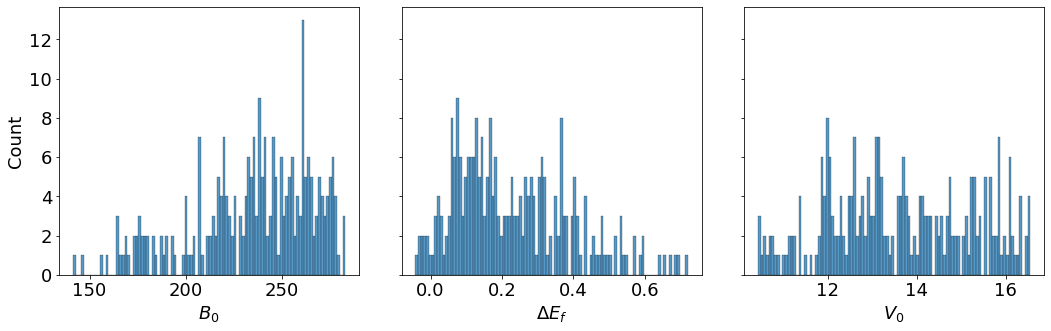

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0], bins=100)
sns.histplot( DS.BS[target_case], ax= ax[1], bins=100)
sns.histplot( DS.BS['V0'], ax= ax[2], bins = 100)
ax[0].set_xlabel('$B_0$')
ax[1].set_xlabel(r'$\Delta E_f$')
ax[2].set_xlabel('$V_0$')
fig.tight_layout()
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_target_distributions_{target_case}.eps')

In [10]:
DS.BS.B0.idxmax()

'Fe_pv4Mo_sv2.C15-A2B.NM'

In [11]:
DS.BS.query('B0 < 150')

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv29.chi.FM,bulk chi.FM,12.050793 A,-8.137580,152.259441 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,29,0,29,1.0,0.0,FM,chi,0.117648,0.117648,0.117648
Fe_pv6.C15.FM,bulk C15.FM,12.092153 A,-8.111059,148.116428 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.021,0,1,...,6,0,6,1.0,0.0,FM,C15,0.144169,0.144169,0.144169


# Machine Learning 

In [12]:
resultslocation = DS.resultslocation

## Feature sets

In [13]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [14]:
for name, featuredf in Features.items():
    if 'BOP' in name:
        print (name )

Canonical BOP
0.7dProjections 0.5OS BOP
0.7spProjections 0.5OS BOP
dataset + Canonical BOP
dataset + 0.7dProjections 0.5OS BOP
dataset + 0.7spProjections 0.5OS BOP
Canonical BOP no CNAV
0.7dProjections 0.5OS BOP no CNAV
0.7spProjections 0.5OS BOP no CNAV
dataset + Canonical BOP no CNAV
dataset + 0.7dProjections 0.5OS BOP no CNAV
dataset + 0.7spProjections 0.5OS BOP no CNAV


In [15]:
Features['SOAP_canonicalW_small no CNAV']

,Structure,Mag,SOAP_0_0,SOAP_1_0,SOAP_2_0,SOAP_3_0,SOAP_4_0,SOAP_5_0,SOAP_6_0,SOAP_7_0,...,SOAP_66_0,SOAP_67_0,SOAP_68_0,SOAP_69_0,SOAP_70_0,SOAP_71_0,SOAP_72_0,SOAP_73_0,SOAP_74_0,random
Fe_pv4Mo_sv20.C36-ABBBB.FM,3,1,0.019930,0.000029,0.006891,-0.004995,0.005019,1.565574e-06,0.000008,-0.000009,...,-7.637395e-07,0.000001,-8.913553e-07,0.000003,-8.029796e-06,0.000009,0.000028,-0.000035,0.000044,0.923881
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4,0,0.019948,-0.000009,0.007036,-0.005294,0.005232,7.452985e-07,-0.000004,0.000002,...,-6.421399e-06,0.000011,-9.087895e-06,0.000012,-2.186196e-05,0.000020,0.000042,-0.000041,0.000041,0.689165
Fe_pv2Mo_sv11.mu-BBABB.FM,9,1,0.019938,0.000014,0.006930,-0.005033,0.005025,1.012184e-06,0.000004,-0.000005,...,-5.744602e-06,0.000008,-5.417666e-06,0.000010,-1.682507e-05,0.000014,0.000035,-0.000035,0.000038,0.891777
Fe_pv8Mo_sv22.sigma-BBBAB.NM,10,0,0.019963,-0.000032,0.007075,-0.005269,0.005169,1.823310e-07,-0.000012,0.000008,...,-9.854544e-06,0.000016,-1.369627e-05,0.000019,-3.378020e-05,0.000031,0.000067,-0.000065,0.000067,0.195819
Fe_pv2Mo_sv11.mu-BBBBA.NM,9,0,0.019938,0.000014,0.006930,-0.005033,0.005025,1.012184e-06,0.000004,-0.000005,...,-5.744602e-06,0.000008,-5.417666e-06,0.000010,-1.682507e-05,0.000014,0.000035,-0.000035,0.000038,0.894263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv8Mo_sv16.C36-BAABB.NM,3,0,0.019918,0.000042,0.006939,-0.005313,0.005342,2.230525e-06,0.000011,-0.000012,...,-5.420279e-07,-0.000002,3.061153e-06,0.000002,-3.821824e-06,0.000004,0.000024,-0.000033,0.000046,0.294892
Fe_pv30.sigma.FM,10,1,0.019820,0.000170,0.007022,-0.006735,0.006903,2.253822e-06,0.000059,-0.000058,...,-1.124610e-05,0.000003,9.347744e-06,0.000017,-1.576315e-05,0.000004,0.000053,-0.000066,0.000102,0.019115
Fe_pv6.C15.FM,2,1,0.019775,0.000255,0.006787,-0.006525,0.006893,1.076990e-05,0.000072,-0.000076,...,-2.123679e-05,-0.000001,2.945842e-05,0.000025,5.152223e-07,-0.000033,0.000004,-0.000008,0.000056,0.363444
Mo_sv8.A15.NM,0,0,0.019972,-0.000034,0.006947,-0.004732,0.004670,7.103624e-08,-0.000012,0.000008,...,-1.395295e-05,0.000022,-1.858555e-05,0.000026,-4.503168e-05,0.000040,0.000086,-0.000082,0.000082,0.316690


In [16]:
Features['NOTHREE-ACE no CNAV'].shape

(262, 282)

## BOP features with and without CP averages

In [17]:
# Features.update({name+' no Zeros': clean_zeros(name, features) for name, features in Features.items() if notyetclean(name)} )

## test - train splits

In [18]:
samplesplit = DS.get_samplesplit()

<AxesSubplot:xlabel='Phase', ylabel='Count'>

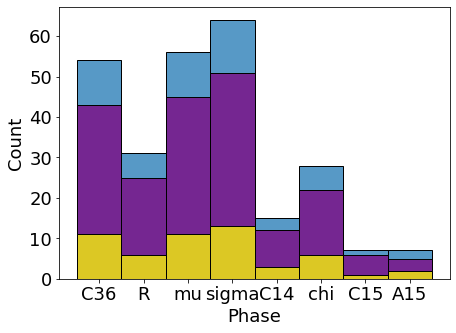

In [19]:
ax = sns.histplot(DS.StructureNames)
sns.histplot(DS.StructureNames.loc[samplesplit['train']], ax = ax, color = 'purple')
sns.histplot(DS.StructureNames.loc[samplesplit['test']], ax = ax, color = 'yellow')

# Models: adjust params

In [20]:
import warnings
warnings.simplefilter('ignore')

In [21]:
Models = {
    'Kernel Ridge': Pipeline([('scaler', StandardScaler()), ('regressor', KernelRidge())]),
    'MLP': Pipeline([('scaler', StandardScaler()), ('regressor', MLPRegressor())]),
    'Random Forest': Pipeline([('regressor', RandomForestRegressor())]),
    'Gaussian Process': Pipeline([('regressor', GaussianProcessRegressor())])
}

In [22]:
from importlib.machinery import SourceFileLoader
MO = SourceFileLoader('MO', 'Tools/DatasetTools/ModelSelection.py').load_module().ModelOptions(DS.dataset)

In [23]:
MO.load_model_options(ModelName)

In [24]:
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, RationalQuadratic, ConstantKernel, ExpSineSquared, DotProduct, Product

##  Features

In [25]:
DS.BS.index[DS.BS.index.str.contains('bcc')]

Index([], dtype='object')

In [26]:
test_bop_feature = '0.7dProjections 0.5OS BOP'

In [27]:
Features[test_bop_feature].index[Features[test_bop_feature].index.str.contains('bcc')]

Index([], dtype='object')

In [28]:
Features[test_bop_feature].index[Features[test_bop_feature].index.str.contains('bcc')]

Index([], dtype='object')

In [29]:
DS.target.index.difference(Features[test_bop_feature].index)

Index([], dtype='object')

In [30]:
for name, thefeatures in Features.items():
    print(name, thefeatures.shape)

atomic (262, 135)
dataset (262, 32)
SOAP_canonicalW_small (262, 453)
SOAP_specific_small (262, 1653)
Pyscal (262, 15)
ACE (262, 1803)
NOZERO-ACE (262, 777)
NOZERO_NOONE-ACE (262, 375)
NOZERO_NOONE_NOTWO-ACE (262, 375)
NOTHREE-ACE (262, 1677)
NOTHREE-NOTWO-ACE (262, 951)
NOTHREE-NOTWO_NOONE-ACE (262, 495)
Canonical ACE (262, 417)
Canonical BOP (262, 405)
0.7dProjections 0.5OS BOP (262, 417)
0.7spProjections 0.5OS BOP (262, 429)
dataset + Canonical BOP (262, 434)
dataset + 0.7dProjections 0.5OS BOP (262, 446)
dataset + 0.7spProjections 0.5OS BOP (262, 458)
atomic no CNAV (262, 135)
dataset no CNAV (262, 17)
SOAP_canonicalW_small no CNAV (262, 78)
SOAP_specific_small no CNAV (262, 278)
Pyscal no CNAV (262, 5)
ACE no CNAV (262, 303)
NOZERO-ACE no CNAV (262, 132)
NOZERO_NOONE-ACE no CNAV (262, 65)
NOZERO_NOONE_NOTWO-ACE no CNAV (262, 65)
NOTHREE-ACE no CNAV (262, 282)
NOTHREE-NOTWO-ACE no CNAV (262, 161)
NOTHREE-NOTWO_NOONE-ACE no CNAV (262, 85)
Canonical ACE no CNAV (262, 72)
Canonical BOP

In [31]:
Features[test_bop_feature].index[Features[test_bop_feature].index.str.contains('bcc')]

Index([], dtype='object')

# Feature Selection

In [32]:
suffix

'no_hcp_bcc_fcc_RandomForest'

In [33]:
feature_concat_resul_loc = os.path.join(DS.dataset, 'results', f'concatenation_results_{target_case}_{suffix}.pkl')  
if os.path.exists(feature_concat_resul_loc):
    with open(feature_concat_resul_loc, 'rb') as pkl:
        savedFCresults = pickle.load(pkl)
else:
    savedFCresults = {}

In [34]:
#with open(feature_concat_resul_loc, 'wb') as f:
#    pickle.dump(savedFCresults, f)

In [35]:
FCresults = {}

In [36]:
for combi, selectionloop in savedFCresults.items():
    print (combi, len(selectionloop))
    FCresults[combi] = []
    for thisloop in selectionloop:
        badnews =  'random' in thisloop.index
        if badnews:
            print(badnews, thisloop.index.get_loc('random'),'/', len (thisloop))
            thisloop=thisloop.loc[:'random'].iloc[:-1]
        else:
            print (badnews, len(thisloop))
        if len(thisloop) < 1:
            continue
        FCresults[combi].append(thisloop)

('Random Forest', 'atomic') 5
False 8
False 8
True 5 / 9
True 8 / 9
True 8 / 9
('Random Forest', 'dataset') 5
False 21
False 21
True 20 / 22
True 21 / 22
True 21 / 22
('Random Forest', 'Canonical ACE') 10
False 197
False 198
True 2 / 198
True 1 / 155
True 17 / 197
True 167 / 202
False 194
False 199
False 196
True 17 / 197
('Random Forest', 'Canonical BOP') 10
False 172
False 130
False 175
False 150
False 173
False 172
False 175
False 105
False 172
False 144
('Random Forest', 'SOAP_canonicalW') 6
False 251
False 251
False 251
False 251
False 251
True 98 / 251
('Random Forest', '0.7dProjections 0.5OS BOP') 10
False 110
False 188
False 99
False 132
False 165
False 73
False 82
False 165
False 80
False 100
('Random Forest', '0.7spProjections 0.5OS BOP') 10
False 101
False 100
False 137
False 89
False 80
False 89
False 168
False 89
False 106
False 140
('Random Forest', 'ACE no CNAV') 10
False 173
False 172
False 166
False 188
False 80
False 139
False 70
False 70
False 158
False 129
('Random 

In [38]:
for combi, selectionloop in FCresults.items():
    print (combi)
    for thisloop in selectionloop:
        badnews =  'random' in thisloop.index
        if badnews:
            print(badnews, thisloop.index.get_loc('random'),'/', len (thisloop))
        else:
            print(badnews, len (thisloop))

('Random Forest', 'atomic')
False 8
False 8
False 5
False 8
False 8
('Random Forest', 'dataset')
False 21
False 21
False 20
False 21
False 21
('Random Forest', 'Canonical ACE')
False 197
False 198
False 2
False 1
False 17
False 167
False 194
False 199
False 196
False 17
('Random Forest', 'Canonical BOP')
False 172
False 130
False 175
False 150
False 173
False 172
False 175
False 105
False 172
False 144
('Random Forest', 'SOAP_canonicalW')
False 251
False 251
False 251
False 251
False 251
False 98
('Random Forest', '0.7dProjections 0.5OS BOP')
False 110
False 188
False 99
False 132
False 165
False 73
False 82
False 165
False 80
False 100
('Random Forest', '0.7spProjections 0.5OS BOP')
False 101
False 100
False 137
False 89
False 80
False 89
False 168
False 89
False 106
False 140
('Random Forest', 'ACE no CNAV')
False 173
False 172
False 166
False 188
False 80
False 139
False 70
False 70
False 158
False 129
('Random Forest', 'ACE')
False 211
False 251
False 116
False 78
False 193
False 2

In [39]:
FCresults.keys()

dict_keys([('Random Forest', 'atomic'), ('Random Forest', 'dataset'), ('Random Forest', 'Canonical ACE'), ('Random Forest', 'Canonical BOP'), ('Random Forest', 'SOAP_canonicalW'), ('Random Forest', '0.7dProjections 0.5OS BOP'), ('Random Forest', '0.7spProjections 0.5OS BOP'), ('Random Forest', 'ACE no CNAV'), ('Random Forest', 'ACE'), ('Random Forest', 'atomic no CNAV'), ('Random Forest', 'dataset no CNAV'), ('Random Forest', '0.7dProjections 0.5OS BOP no CNAV'), ('Random Forest', '0.7spProjections 0.5OS BOP no CNAV'), ('Random Forest', 'SOAP_specific_small'), ('Random Forest', 'SOAP_specific_small no CNAV'), ('Random Forest', 'Canonical ACE no CNAV'), ('Random Forest', 'Canonical BOP no CNAV'), ('Random Forest', 'SOAP_canonicalW_small'), ('Random Forest', 'SOAP_canonicalW_small no CNAV'), ('Random Forest', '0.7dProjections 10scf 8.0jii BOP'), ('Random Forest', '0.7dProjections 10scf 8.0jii BOP no CNAV')])

In [40]:
for combi, results in FCresults.items():
#    if 'SOAP' in combi[1]:
    print (combi, len(results))

('Random Forest', 'atomic') 5
('Random Forest', 'dataset') 5
('Random Forest', 'Canonical ACE') 10
('Random Forest', 'Canonical BOP') 10
('Random Forest', 'SOAP_canonicalW') 6
('Random Forest', '0.7dProjections 0.5OS BOP') 10
('Random Forest', '0.7spProjections 0.5OS BOP') 10
('Random Forest', 'ACE no CNAV') 10
('Random Forest', 'ACE') 10
('Random Forest', 'atomic no CNAV') 10
('Random Forest', 'dataset no CNAV') 10
('Random Forest', '0.7dProjections 0.5OS BOP no CNAV') 10
('Random Forest', '0.7spProjections 0.5OS BOP no CNAV') 10
('Random Forest', 'SOAP_specific_small') 10
('Random Forest', 'SOAP_specific_small no CNAV') 10
('Random Forest', 'Canonical ACE no CNAV') 10
('Random Forest', 'Canonical BOP no CNAV') 10
('Random Forest', 'SOAP_canonicalW_small') 10
('Random Forest', 'SOAP_canonicalW_small no CNAV') 10
('Random Forest', '0.7dProjections 10scf 8.0jii BOP') 1
('Random Forest', '0.7dProjections 10scf 8.0jii BOP no CNAV') 1


In [41]:
nowantoplot = [''] # ['0.6dProjections OS BOP','0.8 Projections OS BOP', 'Projections OS BOP', 'atomic no CNAV', 'dataset no CNAV', 'SOAP_canonicalFe']

In [42]:
iwanttoplot = [combi[1] for combi in FCresults.keys() if combi[0] == ModelName and combi[1] not in nowantoplot and len(FCresults[combi])>0]# and 'no CNAV' not in combi[1] and combi[1] != 'ACE']

## Number of curves for each regressor

In [43]:
for featurename in iwanttoplot:
    print(featurename, len(FCresults[(ModelName, featurename)]))

atomic 5
dataset 5
Canonical ACE 10
Canonical BOP 10
SOAP_canonicalW 6
0.7dProjections 0.5OS BOP 10
0.7spProjections 0.5OS BOP 10
ACE no CNAV 10
ACE 10
atomic no CNAV 10
dataset no CNAV 10
0.7dProjections 0.5OS BOP no CNAV 10
0.7spProjections 0.5OS BOP no CNAV 10
SOAP_specific_small 10
SOAP_specific_small no CNAV 10
Canonical ACE no CNAV 10
Canonical BOP no CNAV 10
SOAP_canonicalW_small 10
SOAP_canonicalW_small no CNAV 10
0.7dProjections 10scf 8.0jii BOP 1
0.7dProjections 10scf 8.0jii BOP no CNAV 1


In [44]:
iwanttoplot

['atomic',
 'dataset',
 'Canonical ACE',
 'Canonical BOP',
 'SOAP_canonicalW',
 '0.7dProjections 0.5OS BOP',
 '0.7spProjections 0.5OS BOP',
 'ACE no CNAV',
 'ACE',
 'atomic no CNAV',
 'dataset no CNAV',
 '0.7dProjections 0.5OS BOP no CNAV',
 '0.7spProjections 0.5OS BOP no CNAV',
 'SOAP_specific_small',
 'SOAP_specific_small no CNAV',
 'Canonical ACE no CNAV',
 'Canonical BOP no CNAV',
 'SOAP_canonicalW_small',
 'SOAP_canonicalW_small no CNAV',
 '0.7dProjections 10scf 8.0jii BOP',
 '0.7dProjections 10scf 8.0jii BOP no CNAV']

In [45]:
pallete = sns.color_palette(n_colors=len(iwanttoplot))

In [46]:
colors = {name: c for name, c in zip(iwanttoplot, pallete)}

In [47]:
# iwanttoplot = ['atomic', 'dataset', 'Canonical BOP', 'dataset + Canonical BOP', 'Projections BOP', 'dataset + Projections BOP', 'Projections sOS BOP', 'dataset + Projections sOS BOP' ]
#iwanttoplot = ['ACE','SOAP_specific_small',  'Canonical BOP', 
#iwanttoplot = ['Projections OS BOP']#, 'Projections sOS BOP']#, 'SOAP_canonicalW',

In [48]:
folder = StratifiedKFold(shuffle=True)
folds_generator = folder.split(DS.samplesplit['train'], DS.StructureNames[DS.samplesplit['train']])
train_folds = list(folds_generator)
TestCV = GridSearchCV(Models[ModelName], MO.modeloptions[ModelName], cv = train_folds, return_train_score=True)

In [49]:
FittedGS = {}

In [50]:
MO.modeloptions

{'Random Forest': {'regressor__max_depth': [5, 10],
  'regressor__min_samples_split': [2],
  'regressor__min_samples_leaf': [1, 10],
  'regressor__max_leaf_nodes': [None, 20, 30]}}

# Some old code
``` python
# DS.Features.keys(): #['Canonical BOP']:
for featurename in iwanttoplot: #FittedModels.items():
    print(featurename)
    if 'random' not in Features[featurename]:
        Features[featurename]['random'] = np.random.rand(DS.target.shape[0])
    corrs = pd.concat([Features[featurename], DS.target], axis=1).corr().abs()[target_case]
    
    reasonable_features = corrs[corrs > corrs['random']].index.difference([target_case])
    combi = (ModelName, featurename)
#   model = copy.deepcopy(fmodel.best_estimator_)
    if len(FCresults[combi]) >= 1 :
        continue
    FittedGS[combi] = copy.deepcopy(TestCV)
    FC = FeatureConcatenate(DS, FittedGS[combi],  MO.modeloptions[ModelName]) #fmodel.best_params_,)model_params_grid =
    FCresults[combi].append (FC.get_best_features_list(combi[1], num_features = 2, max_workers=3, search_only = reasonable_features))#DS.Features[combi[1]].shape[1]
    with open(feature_concat_resul_loc, 'wb') as pkl:
        pickle.dump(FCresults, pkl)
```

In [51]:
#with open(feature_concat_resul_loc, 'wb') as pkl:
#    pickle.dump(FCresults, pkl)

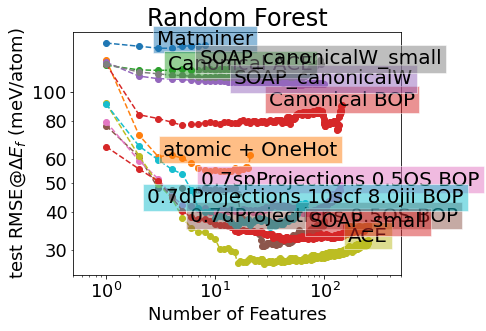

In [52]:
from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots()
for combi, result in FCresults.items():
    if len(result) < 1:
        continue
    if combi[0] != ModelName:
        continue
    if combi[1] not in iwanttoplot:
        continue
    if 'no CNAV' in combi[1]:
        continue
#    if ' OS ' in combi[1]:
#        continue
    nfeats = result[-1].shape[0]
    x=np.linspace(1,nfeats, nfeats)
    legend = combi[1].replace('dataset', 'polyhedra')
    legend = legend.replace('atomic', 'Matminer')\
        .replace('_specific','').replace('0.7 ','')\
        .replace('polyhedra','atomic + OneHot')\
        .replace('Projections OS BOP', 'Bond Specific BOP')
    if 'test' not in result[-1].keys():
        continue
    y = result[-1]['test'].values*1000
    axes.plot(x, y ,'--o',c=colors[combi[1]], label=legend)
    text = axes.text(x[-1], y[-1], legend, horizontalalignment='center')#, backgroundcolor='white', alpha=0.5)
    text.set_bbox(dict(facecolor=colors[combi[1]], alpha=0.5,edgecolor='white'))
axes.set_xscale('log')
axes.set_ylabel(r'test RMSE@$\Delta E_f$ (meV/atom)')
axes.set_xlabel('Number of Features')
axes.tick_params(axis='y', which='minor')
axes.set_yscale('log', subs = [0.2, 0.3, 0.4,0.5, 0.6, 0.8])
axes.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
axes.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
#plt.legend(bbox_to_anchor=(0.6,0.5))
axes.set_xlim([0.5, 0.5e3])
axes.set_title(ModelName)
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_{target_case}_{nameforfile}.pdf')

In [53]:
'Mag' in FCresults[(ModelName, test_bop_feature )][-1].index

True

In [54]:
#'Structure' in
theindex = FCresults[(ModelName, test_bop_feature )][-1].index

In [55]:
FCresults[(ModelName, test_bop_feature )][-1].reset_index()[theindex=='Structure']

,index,train1,test1,params,test,train


In [56]:
combi = (ModelName, test_bop_feature)
selected_pos = FCresults[combi][-1].index[0]
y_pos = FCresults[combi][-1]['test']*1000
x = np.linspace(1, len(y_pos), len(y_pos))
axes.annotate(get_str_formatted(selected_pos), (x[0], y_pos[0]-5), xytext=(x[0]-0.1, y_pos[0]-40), arrowprops={'facecolor':'black'})
selected_next = FCresults[combi][-1].index[1]
axes.annotate(get_str_formatted(selected_next), (x[1], y_pos[1]), xytext=(x[1]*2, y_pos[1]+20), arrowprops={'facecolor':'black'})
ymag = y_pos[y_pos.index=='Mag']['Mag']
xmag = x[y_pos.index=='Mag']
axes.annotate('Mag', (xmag-0.1, ymag-1), xytext=(xmag/5, ymag-10), arrowprops={'facecolor':'black'})
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_annotated_{target_case}_CV.pdf')

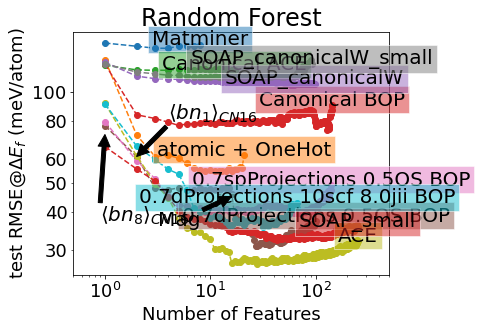

In [57]:
fig

## Feature Selection

In [58]:
iwanttoplot_all = [feature for feature in iwanttoplot if 'no CNAV' not in feature and 'dataset' not in feature and 'atomic' in feature]

In [59]:
iwanttoplot_all = {
    test_bop_feature: 'BOP',  
    'ACE':'ACE',
    'SOAP_specific_small': 'SOAP',
    'dataset': 'atomic + OneHot', 
    'Canonical BOP': 'Canonical BOP',
    'SOAP_canonicalW_small' : 'Canonical SOAP',
    'Canonical ACE': 'Canonical ACE'
}

In [60]:
from matplotlib import __version__

In [61]:
iwanttoplot_all

{'0.7dProjections 0.5OS BOP': 'BOP',
 'ACE': 'ACE',
 'SOAP_specific_small': 'SOAP',
 'dataset': 'atomic + OneHot',
 'Canonical BOP': 'Canonical BOP',
 'SOAP_canonicalW_small': 'Canonical SOAP',
 'Canonical ACE': 'Canonical ACE'}

In [62]:
def plot_panel_learning_curves(feature_list: dict):# -> list[matplotlib.axes._subplots.Axes]: 
    nplots = len(feature_list)
    width = plt.rcParams['figure.figsize'][0]*(3/5)*nplots
    height = plt.rcParams['figure.figsize'][1]
    fig, axes = plt.subplots(1,nplots, figsize=(width, height), sharey = True)# figsize=(width, 5*width/13),
    for (featurename, featurelabel), ax in zip(feature_list.items(), axes):
        combi = (ModelName, featurename)
        ax.set_title(featurelabel)
        results = FCresults[combi]
        for j, result in enumerate(results):
            x = np.linspace(1, result.shape[0], result.shape[0])
            if 'test' not in result.keys():
                continue
            sns.scatterplot(x=x, y=result['test']*1000, ax=ax)
        N = Features[featurename].shape[1]
        NL = len(results)
        ax.legend([],[],title=f'N = {N}\n NL = {NL}')
        ax.set_yscale('log', subs=[2, 6, 10])
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
#    ax.set_ylim([19, 110])
    ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
    ax.tick_params(axis='y', which = 'minor')
    axes[0].set_xticks([1, 5, 10])
    axes[0].set_ylabel(r'test RMSE @$\Delta E_f$ (meV/at)')
    fig.supxlabel('Number of features')
    return fig, axes
#    axes[i-1].set_xticklabels('')
#axes[0].yaxis.set_major_formatter(FormatStrFormatter("%.0e"))

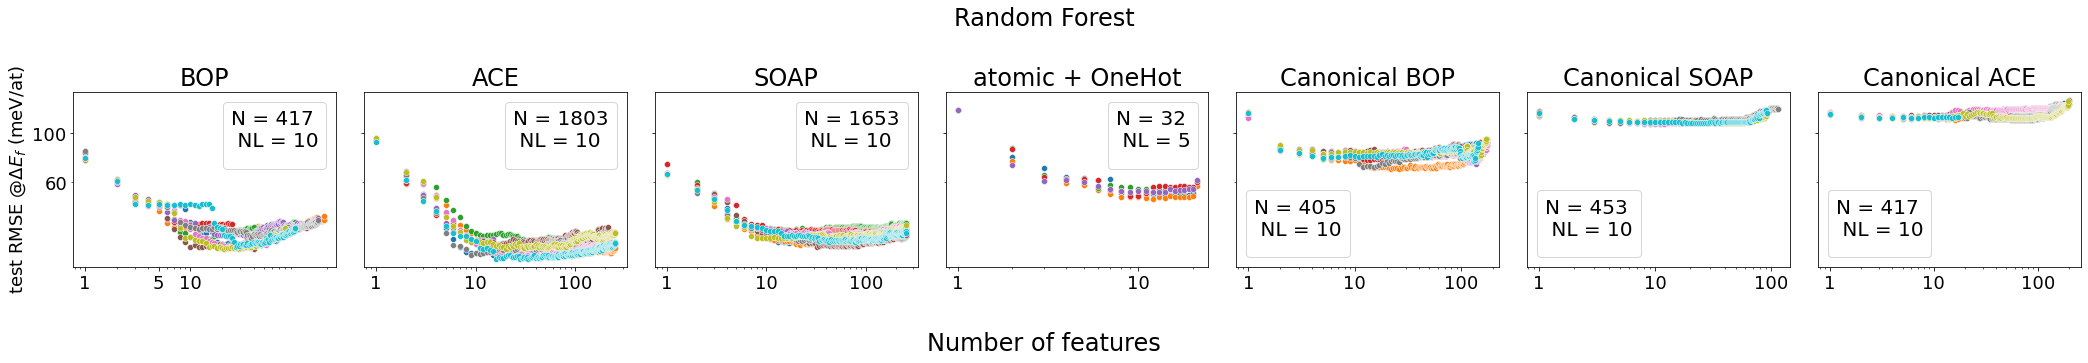

In [63]:
fig, axes = plot_panel_learning_curves(iwanttoplot_all)
nameinfile = ModelName.replace(' ','')
fig.suptitle(ModelName)
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_{nameinfile}_learning_curves_tovote.pdf'))

# Feature transformers

In [64]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import RegressorMixin
from Tools.DatasetTools.MLConveniences import filter_features, get_optimal_features

In [65]:
def get_optimal_feature_score(FeatureScoreData:pd.core.frame.DataFrame):
    thisatmin = FeatureScoreData['test'].argmin()
    return FeatureScoreData[:thisatmin]

In [66]:
#def get_optimal_features(FeatureScoreData:pd.core.frame.DataFrame, remove_structure = False):
#    thisatmin = FeatureScoreData['test'].argmin()
#    optimal_features = FeatureScoreData.index[:thisatmin]
#    if remove_structure:
#        optimal_features=optimal_features[optimal_features != 'Structure']
#    return optimal_features # FeatureScoreData.index[:thisatmin]

In [67]:
#def filter_features (Features_DF: pd.core.frame.DataFrame, learning_curve = pd.core.frame.DataFrame, remove_structure = True):
#    if 'params' not in learning_curve.columns:
#        raise ValueError('the learning curve provided is not an evaluation of best features')
#    columns = get_optimal_features(learning_curve,remove_structure = remove_structure)
#    return Features_DF[columns]

#def get_optimal_feature_names(Features_DF: pd.core.frame.DataFrame, learning_curve = pd.core.frame.DataFrame):
#    columns = get_optimimal_features(learning_curve)
#    return columns


In [68]:
#class AverageEnsambleRegressor():
#    def __init__(self, named_estimators = list[tuple[str, RegressorMixin]]):
#        self.named_estimators_ : list[tuple[str, RegressorMixin]] = named_estimators
#
#    def fit(self, _X : pd.core.frame.DataFrame , _Y : pd.core.series.Series) -> pd.core.series.Series:
#
#        for name, estimator in self.named_estimators_:
#            estimator.fit(_X, _Y)
#
#    def predict(self, _X : pd.core.frame.DataFrame) -> pd.core.series.Series:
#
#        self.predictions_ = pd.concat(
#            [pd.Series(estimator.predict(_X), name=name, index=_X.index) for name, estimator in self.named_estimators_],
#            axis=1
#        )
#
#        return self.predictions_.mean(axis=1)
#
#    def get_prediction_std(self):
#        if not hasattr(self, 'predictions_'):
#            pdb.set_trace()
#            raise NameError('you must fit the models first')
#
#        err = self.predictions_.std(axis=1)
#        return err

In [69]:
combi = (ModelName, test_bop_feature)

In [70]:
RegresorsBag = {}

In [71]:
from sklearn.ensemble import VotingRegressor

In [72]:
VotedScores = {}
AveragedScores = {}

In [73]:
voting_regressor = {}
average_regressor = {}
indexedregressorbag = {}

## Voting Regressor based on regressor bag

In [74]:
import logging
Logger = logging.getLogger()
Logger.setLevel(logging.INFO)

In [81]:
combi[1]

'0.7dProjections 10scf 8.0jii BOP no CNAV'

In [83]:
FCresults.keys()

dict_keys([('Random Forest', 'atomic'), ('Random Forest', 'dataset'), ('Random Forest', 'Canonical ACE'), ('Random Forest', 'Canonical BOP'), ('Random Forest', 'SOAP_canonicalW'), ('Random Forest', '0.7dProjections 0.5OS BOP'), ('Random Forest', '0.7spProjections 0.5OS BOP'), ('Random Forest', 'ACE no CNAV'), ('Random Forest', 'ACE'), ('Random Forest', 'atomic no CNAV'), ('Random Forest', 'dataset no CNAV'), ('Random Forest', '0.7dProjections 0.5OS BOP no CNAV'), ('Random Forest', '0.7spProjections 0.5OS BOP no CNAV'), ('Random Forest', 'SOAP_specific_small'), ('Random Forest', 'SOAP_specific_small no CNAV'), ('Random Forest', 'Canonical ACE no CNAV'), ('Random Forest', 'Canonical BOP no CNAV'), ('Random Forest', 'SOAP_canonicalW_small'), ('Random Forest', 'SOAP_canonicalW_small no CNAV'), ('Random Forest', '0.7dProjections 10scf 8.0jii BOP'), ('Random Forest', '0.7dProjections 10scf 8.0jii BOP no CNAV')])

In [85]:
for combi, learningcurvelist in FCresults.items():
    if combi[1] not in Features.keys():
        continue
        
    for i, learningcurve in enumerate(learningcurvelist):
        intersection = Features[combi[1]].columns.intersection(learningcurve.index)
        print(f'learning curve {i} from {combi} generates {len(intersection)} transform')
        if len(intersection) == 1:
            print(intersection)


learning curve 0 from ('Random Forest', 'atomic') generates 8 transform
learning curve 1 from ('Random Forest', 'atomic') generates 8 transform
learning curve 2 from ('Random Forest', 'atomic') generates 5 transform
learning curve 3 from ('Random Forest', 'atomic') generates 8 transform
learning curve 4 from ('Random Forest', 'atomic') generates 8 transform
learning curve 0 from ('Random Forest', 'dataset') generates 21 transform
learning curve 1 from ('Random Forest', 'dataset') generates 21 transform
learning curve 2 from ('Random Forest', 'dataset') generates 20 transform
learning curve 3 from ('Random Forest', 'dataset') generates 21 transform
learning curve 4 from ('Random Forest', 'dataset') generates 21 transform
learning curve 0 from ('Random Forest', 'Canonical ACE') generates 197 transform
learning curve 1 from ('Random Forest', 'Canonical ACE') generates 198 transform
learning curve 2 from ('Random Forest', 'Canonical ACE') generates 2 transform
learning curve 3 from ('Rando

In [86]:
for combi, LearningCurveList in FCresults.items():
    Logger.info(f'{combi}')
    RegresorsBag[combi] = []
    if combi[1] not in Features.keys():
        continue
    if combi[0] != ModelName:
        continue
    if len(LearningCurveList) < 1:
        continue
    for LearningCurve in LearningCurveList:
        if len(LearningCurve) < 1:
            continue
        transformer = FunctionTransformer(
            filter_features, kw_args = {'learning_curve' : LearningCurve, 'remove_structure' : True},
        )
        RegresorsBag[combi].append(copy.deepcopy(Models[ModelName])) 
        RegresorsBag[combi][-1].steps.insert(0, ['feature_selection', transformer])
        thiscurve = LearningCurve
        RegresorsBag[combi][-1].set_params(**thiscurve.params.iloc[-1])

    if len(RegresorsBag[combi]) < 1:
        continue
    indexedregressorbag[combi] = [(str(i), thisregressor) for i, thisregressor in enumerate(RegresorsBag[combi])]

    voting_regressor[combi] = VotingRegressor(indexedregressorbag[combi])


INFO:root:('Random Forest', 'atomic')
INFO:root:('Random Forest', 'dataset')
INFO:root:('Random Forest', 'Canonical ACE')
INFO:root:('Random Forest', 'Canonical BOP')
INFO:root:('Random Forest', 'SOAP_canonicalW')
INFO:root:('Random Forest', '0.7dProjections 0.5OS BOP')
INFO:root:('Random Forest', '0.7spProjections 0.5OS BOP')
INFO:root:('Random Forest', 'ACE no CNAV')
INFO:root:('Random Forest', 'ACE')
INFO:root:('Random Forest', 'atomic no CNAV')
INFO:root:('Random Forest', 'dataset no CNAV')
INFO:root:('Random Forest', '0.7dProjections 0.5OS BOP no CNAV')
INFO:root:('Random Forest', '0.7spProjections 0.5OS BOP no CNAV')
INFO:root:('Random Forest', 'SOAP_specific_small')
INFO:root:('Random Forest', 'SOAP_specific_small no CNAV')
INFO:root:('Random Forest', 'Canonical ACE no CNAV')
INFO:root:('Random Forest', 'Canonical BOP no CNAV')
INFO:root:('Random Forest', 'SOAP_canonicalW_small')
INFO:root:('Random Forest', 'SOAP_canonicalW_small no CNAV')
INFO:root:('Random Forest', '0.7dProjec

In [89]:
y = DS.target.loc[DS.samplesplit['train']]
for combi, votingregressor in voting_regressor.items():
    xtrain = Features[combi[1]].loc[DS.samplesplit['train']]
    voting_regressor[combi].fit(xtrain, y )


    VotedScores[combi] = score_fitted_model(
        voting_regressor[combi], 
        Features[combi[1]].loc[DS.samplesplit['train']],
        Features[combi[1]].loc[DS.samplesplit['test']],
        DS.target[DS.samplesplit['train']],
        DS.target[DS.samplesplit['test']])

ValueError: at least one array or dtype is required

In [88]:
voting_regressor[combi]

VotingRegressor(estimators=[('0',
                             Pipeline(steps=[['feature_selection',
                                              FunctionTransformer(func=<function filter_features at 0x7fbae38bd940>,
                                                                  kw_args={'learning_curve':                                      train1     test1  \
canonical_ace_projections_16_CN16  0.101030  0.129884   
canonical_ace_projections_32_CN13  0.100284  0.129893   
canonical_ace_projections_40_CN13  0.100287  0.129824   
Mag                                0.091643  0.132265   
canonical...
canonical_ace_projections_9_CN13   0.118404  0.110389  
canonical_ace_projections_14_CN13  0.118597  0.111390  
canonical_ace_projections_33_CN12  0.119033  0.100578  
Mag                                0.117472  0.098108  
canonical_ace_projections_10_CN13  0.117986  0.097974  
canonical_ace_projections_65_CN12  0.118202  0.087906  ,
                                                                           'remove_structure': True})],
                                             ('regressor',
                                              RandomForestRegressor(max_depth=5,
                                                                    max_leaf_nodes=30))]))])

In [86]:
#
voting_regressor[combi].fit(Features[combi[1]].loc[DS.samplesplit['train']], DS.target.loc[DS.samplesplit['train']])

ValueError: at least one array or dtype is required

In [ ]:
for combi, votingregressor in voting_regressor.items():
    for index, pipeline in votingregressor.estimators:
        pipeline.named_steps['feature_selection'].func#__dict__.keys()
        learning_curve = pipeline.named_steps['feature_selection'].kw_args['learning_curve']
        transformed_features = pipeline.named_steps['feature_selection'].transform(Features[combi[-1]])
        has_struc = 'Structure' in transformed_features.columns
        where_struc = None
        if has_struc: 
            where_struc = transformed_features.columns.get_loc('Structure')
            print(combi, len(learning_curve), 'transformed has structure: ',  has_struc, where_struc)

# SAVE THE REGRESSOR!

In [ ]:
regresorbag_file =os.path.join(DS.dataset, 'results', f'regressors_bag_{nameforfile}.pkl')

In [ ]:
indexedbags_file = os.path.join(DS.dataset, 'results', f'indexed_bag_{nameforfile}.pkl')

In [ ]:
regressor_file = os.path.join(DS.dataset, 'results', f'voting_regressor_{nameforfile}.pkl')

In [ ]:
joblib.dump(RegresorsBag, regresorbag_file)
joblib.dump(indexedregressorbag, indexedbags_file)
joblib.dump(voting_regressor, regressor_file)

['Fe-Mo/results/voting_regressor_RandomForest.pkl']

In [ ]:
voting_regressor = joblib.load(regressor_file)

In [ ]:
os.path.exists(regressor_file)

True

In [76]:
voting_regressor[(ModelName, 'SOAP_canonicalW_small')]

KeyError: ('Random Forest', 'SOAP_canonicalW_small')

In [ ]:
err_test = {}
for (featurename, featuretag), ax in zip(iwanttoplot_all.items(), axes):
    ax.grid('on')
    if featurename not in Features.keys():
        continue
    combi = (ModelName, featurename)
    if combi not in voting_regressor.keys():
        continue
    bagging_regressor = voting_regressor[combi]
    err_test[featurename] = (bagging_regressor.predict(Features[featurename].loc[DS.samplesplit['test']]) - DS.target[DS.samplesplit['test']]).abs()

NotFittedError: This VotingRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [87]:
min_err_test =min( [  err.min() for err in err_test.values() ] )

In [ ]:
min_err_test

In [ ]:
max_err_test =min( [  err.max() for err in err_test.values() ] )

In [ ]:
max_err_test

In [ ]:
logbins = np.logspace(np.log10(min_err_test*1000), np.log10(max_err_test*1000), 10)

In [ ]:
VotedScores

``` python
nplots = len(iwanttoplot_all)
width = nplots*plt.rcParams['figure.figsize'][0]*(3/5)
height = plt.rcParams['figure.figsize'][1]
fig, axes = plt.subplots(1, nplots, sharex = True, sharey = True, figsize=(width, height))

for (featurename, featuretag), ax in zip(iwanttoplot_all.items(), axes):
    ax.grid('on')
    if featurename not in Features.keys():
        continue
    combi = (ModelName, featurename)
    bagging_regressor = voting_regressor[combi]
#    err_test = (bagging_regressor.predict(Features[featurename].loc[DS.samplesplit['test']]) - DS.target[DS.samplesplit['test']]).abs()
#    rmse_test = np.sqrt((err_test[featurename]**2).sum()/len(err_test))
    rmse_test = VotedScores.loc[(ModelName, featurename)]['test']
    ax = sns.histplot(
        data=err_test[featurename],
        y=err_test[featurename].values*1000, 
        ax=ax,  #binrange=[0, 100],
        bins=logbins, #50, 
        color = ['blue'],
        edgecolor = 'black',
        linewidth = 2
    )#, hue =DS.StructureNames[DS.samplesplit['test']])#.plot.hist( ax=ax)
    ax.set_xlabel('')
    ax.set_title(f'{featuretag} {len(err_test[featurename])}' )
    ax.axhline(np.log10(err_test[featurename].std()*1000), color='mediumseagreen', label = 'std', linewidth = 5)
    ax.axhline(np.log10(rmse_test*1000), color='crimson', label = 'RMSE', linewidth = 5)
    ax.axhline(np.log10(err_test[featurename].mean()*1000), label='MAE', color='chocolate', linewidth=5)
#    ax.get_legend().remove()
axes[0].set_ylabel(r'$|\Delta E_f ^{predict} - \Delta E_f ^{target}|_{test}$ (meV/at)')
axes[0].set_yscale('log')
fig.supxlabel('Counts', x=0.5, y=0.05)
fig.suptitle(ModelName)
fig.tight_layout()
leg_handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(leg_handles, leg_labels, ncol=3)
fig_file_name = os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_{nameforfile}_ErrorDistributions_{target_case}.pdf')
plt.savefig(fig_file_name)
```

VotedScores.loc[(ModelName, 'ACE')]

In [ ]:
VotedScores = pd.DataFrame.from_dict(VotedScores, orient = 'index')

In [ ]:
VotedScores

In [ ]:
VotedScores = VotedScores.sort_values('test', ascending = False).sort_index(level=1)

In [ ]:
VotedScores

In [ ]:
VotedScores.to_pickle(os.path.join(DS.dataset,'results', f'{DS.dataset}_{ModelName}_OptimalScores_{target_case}.pkl'))

In [ ]:
PlotVotedScores = 1000*VotedScores[~VotedScores.index.levels[1].str.contains('^0.6|^0.8')]

In [ ]:
unstack = PlotVotedScores.unstack(level=0).sort_index()

In [ ]:
ax = PlotVotedScores.unstack(level=0).sort_index().plot.bar(
    color = ['dodgerblue', 'peru'], edgecolor = 'black'
)#.sort_values(by=('test', ModelName), ascending=False)*1000).plot.bar()
ax.set_yscale('log', subs=[2,3, 4, 6, 8, 10])
ax.get_legend().set_title('')
ax.tick_params(axis='y', which = 'minor')                                                                                                     
ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

# Feature Importances 

In [95]:
def loop_get_importances(voting_regressor):
    importances = {}
    for combi, estimator in voting_regressor.items():
        print(combi[1])
        X = DS.Features[combi[1]]#[selected]
        allimportances = get_importances(estimator , X,  DS.target)
        importances[combi] =allimportances #  [allimportances['importances_mean']>=allimportances['importances_mean']['random']]
    for (modelname, name),timportances in importances.items():
        timportances.sort_values(by='importances_mean', inplace=True, ascending=False)
    return importances


In [96]:
def plot_importances(importances):
    for name, timp in importances.items():
        fig, ax = plt.subplots(figsize=(12, 8))
        x = timp['importances_mean'][:20]
        sns.barplot(y=timp.index[:20], x=x , ax=ax, color='Purple')
        ylabels = [get_str_formatted(fname) for fname in x.index]
        ax.set_xscale('log')
        ax.set_xlabel('permutation importance')
        ax.set_yticklabels(ylabels, fontsize=12)
        fig.suptitle(name[1].replace('dataset', 'polyhedra'))
        fig.tight_layout()

In [ ]:
importances = loop_get_importances(voting_regressor)

0.7spProjections 0.5OS BOP
0.7dProjections 0.5OS BOP
atomic
dataset
Canonical ACE
ACE no CNAV
ACE
atomic no CNAV
dataset no CNAV
0.7dProjections 0.5OS BOP no CNAV
0.7spProjections 0.5OS BOP no CNAV
SOAP_specific_small


In [ ]:
for combi, bag_of_curves in FCresults.items():
    if combi not in importances.keys():
        continue
#    if '0.7dProjections 0.5OS BOP' in combi:
#        break

    relevant_importances = importances[combi].query('importances_mean > 0')/importances[combi].max()
    nrelevant = len(relevant_importances)

    locs = {}

    for featurename, importance in relevant_importances.iterrows():
        locs[featurename] = {i: curve.index.get_loc(featurename) for i, curve in enumerate(bag_of_curves) if featurename in curve.index}
            
    locs = pd.DataFrame.from_dict(locs, orient='index', dtype= int)
    locs['mean'] = locs.mean(axis=1)
    locs.sort_values(by='mean', inplace=True)
    locs['std'] = locs.drop(columns=['mean']).std(axis = 1)
    locs.dropna(inplace=True)
    if len(locs) == 0:
        continue
    indexing = pd.Series(np.linspace(0, len(relevant_importances)-1, len(relevant_importances)), index=relevant_importances.index, name='indexing')
    indexed_locs = pd.concat([indexing, locs], axis=1)
    fig, ax = plt.subplots(figsize=(8,0.5*(nrelevant+1)))
    fig.suptitle(f'{combi}', x=0, fontsize=12)
    axup= ax.twiny()
    ax.barh(y = indexing, width=relevant_importances['importances_mean'])
    axup.stem(indexed_locs['indexing'],indexed_locs['mean'],  orientation='horizontal', linefmt='r', markerfmt='dr')
    #axup.stem(indexing[locs.index],locs['mean'],  orientation='horizontal', linefmt='b', markerfmt='o')
    axup.set_xlim([0, locs['mean'].max()])
    axup.set_xlabel('position in selection vector')
    ax.set_yticks(indexing)
    labels = ax.set_yticklabels(relevant_importances.index)
    axup.spines['top'].set_color('red')
    #locs.plot(x='std')
    #axs[0].set_xscale('log')

In [ ]:
for FCresults[('Model')]

# Prediction line 

In [ ]:
from sklearn.ensemble._voting import VotingRegressor as type_voting_regressor

In [ ]:
def get_bag_of_predictions(bag_of_regressors : type_voting_regressor, features_df  : pd.core.frame.DataFrame):
    bag_of_predictions = {}
    for name, regressor_in_bag in enumerate(bag_of_regressors):
        bag_of_predictions[name] = regressor_in_bag.predict(features_df)
        bag_of_predictions [name] = pd.Series(bag_of_predictions[name],name=name,  index=features_df.index)
    return pd.concat(bag_of_predictions, axis=1)
    

In [ ]:
predictions={}
stds={}
Prediction = {} 

In [ ]:
for name, regressor in voting_regressor.items():
    Prediction[name] = regressor.predict(Features[name[1]])
    Prediction[name] = pd.DataFrame(Prediction[name], index = Features[name[1]].index, columns=[DS.target_name])
    predictions[name] = get_bag_of_predictions(regressor.estimators_, Features[name[1]])
    stds[name] = predictions[name].std(axis=1)

# Predicted BS 

In [ ]:
predictedBS = copy.copy(DS.BS.loc[DS.target.index])

In [ ]:
for combi, prediction in Prediction.items():
    predictedBS[f'EF_nmhcp_{combi[1]}'] = prediction

In [ ]:
predictedBS.filter(regex='EF_nmhcp_*')

## save the prediction

In [ ]:
#predictedBS.to_pickle(os.path.join(DS.dataset, 'results', f'{DS.dataset}_{ModelName}_PredictedBS.pkl'))


In [ ]:
#iwanttoplot = {'atomic':'Matminer',
iwanttoplot = {'dataset': 'atomic+oneHot', test_bop_feature:'Bond specific BOP'}
#iwanttoplot = {'dataset': 'dataset', 'Projections OS BOP':'Projections OS BOP'}

In [ ]:
x_y = np.linspace(DS.target.min()-0.1, DS.target.max()+0.1, 2)
fig, ax = plt.subplots()
ax.plot(x_y, x_y, '--k', lw=2)
for name, legend in iwanttoplot.items():
    print(name, legend)
    legend = legend.replace('dataset', 'polyhedra').replace('Bond specific BOP', 'BOP')
    combi = (ModelName, name)
    if combi not in Prediction.keys():
        print(f'{combi} has not been processed yet')
        continue
    ax.plot(Prediction[combi].values, DS.target.values, 'o', markersize=8, markeredgecolor='k', color=colors[name], label=legend, )
ax.set_xlabel(r'predicted $\Delta E_f$ (eV/atom)')
ax.set_ylabel(r'True $\Delta E_f$ (eV/atom)')
ax.legend()
fig.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_{ModelName}_predictionline_{target_case}.pdf'))

# Recursivity

REDO RECURSIVITY TESTS
 - redefine model
 - refit model

In [ ]:
Tester = DatasetTester()

In [ ]:
from importlib.machinery import SourceFileLoader
Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
# from Tools.DatasetTools.DatasetOperator import Dataset
# DS = SourceFileLoader('DS', 'Tools/DatasetTools/DatasetOperator.py').load_module().Dataset('Fe-Mo')
# Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
# samplesplit = DS.get_samplesplit()

In [ ]:
import copy

In [ ]:
RecursivityModels = copy.deepcopy(Models[ModelName])

# Fits on reduced features 

In [ ]:
ReducedFittedModels = {}

In [ ]:
Reduced_features_fitting_location = os.path.join(DS.resultslocation, f'ReducedFeaturesCVSearch_{target_case}.pkl')

In [ ]:
#if os.path.exists(Reduced_features_fitting_location):
#    with open(Reduced_features_fitting_location, 'rb') as pkl:
#        ReducedFittedModels = pickle.load(pkl)

In [ ]:
MO.modeloptions

In [ ]:
maxorders = [8, 10, 12, 14, 16]
for name, model in Models.items():
    if name != ModelName:
        continue
    progress = tqdm(product(Features.items(), maxorders), total=len(maxorders)*len(Features))
    for (key, features), maxorder in progress:  # maxorder in range(4,9):
        progress.set_description(name+', '+key+', '+str(maxorder)+':  ')
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if 'no CNAV' in key:
            continue
        if 'BOP' not in key:
            continue
        if 'Projections' not in key:
            continue
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if maxorder < 10:
            regexstr = f'^(?!.*_[{maxorder}-9]_.*|.*_1[0-9]_.*)'
        else:
            regexstr = f'^(?!.*_1[{maxorder - 10}-9]_.*)'
#        for key, features in progress: #Features.items():
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = 5,#samplefolds,
            return_train_score= True,
        )
        if 'BOP' in key:
            reducedfeatures = features.filter(regex=regexstr)
        else:
            reducedfeatures = features
        ReducedFittedModels[(name, key, maxorder)] = model.fit(reducedfeatures, DS.target)

In [ ]:
with open(Reduced_features_fitting_location, 'wb') as pkl:
    pickle.dump(ReducedFittedModels, pkl)

In [ ]:
somecombi = (ModelName, 'Projections BOP')

In [ ]:
features_in_reduced = pd.Index(ReducedFittedModels[somecombi+(16,)].feature_names_in_)

In [ ]:
best_scores_reduced = collect_best_scores(ReducedFittedModels)

In [ ]:
model = best_scores_reduced.index.get_level_values(0)

In [ ]:
test_scores_vs_max = best_scores_reduced.unstack().transpose().loc['test'].dropna(axis=1)

In [ ]:
full_model_test_scores = best_scores_reduced.unstack().transpose().loc['test']

In [ ]:
fig, ax = plt.subplots(figsize=(15, 8))
for combi in test_scores_vs_max.columns:
#    if 'BOP' not in combi[1]:
#        continue
#    if 'Canonical' in combi[1]:
#        continue
#    if 'dataset' not in combi[1]:
#        continue
    drmse = (test_scores_vs_max[combi].values - test_scores_vs_max[combi].values[-1])*1000  # - full_model_test_scores[combi[0]][combi[1]]*1000
    l = ax.plot(test_scores_vs_max[combi].index, drmse, label=combi[1])[0]
#    ax.axhline(full_model_test_scores[combi[0]][combi[1]]*1000,ls='--', color=l.get_color())
ax.legend(bbox_to_anchor = (1, 1))
ax.set_ylabel(r'$\Delta$ test RMSE($\Delta E_f$) (meV/atom)')
ax.set_xlabel(r'max order in recursion features: $a_{1,..,n/2}, b_{1,..,n/2}, \mu_{1,..,n}, \sigma_{1,...,n}$')
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_full_recursivity_{target_case}.eps'))

# Errors by phase by model

In [ ]:
train_errors = {}
rmse = {}

In [ ]:
absolute_errors = {}

In [ ]:
iwanttoseeerrors = ['0.7 Projections OS BOP', 'SOAP_specific', 'ACE']

In [ ]:
for combi, thisprediction in Prediction.items(): # voting_regressor.items():
    if 'sOS' in combi[1]:
        continue
    if combi[1] not in iwanttoseeerrors:
        continue
    print(combi)
    absolute_errors[combi] = thisprediction.sub(DS.target, axis=0)
    rmse[combi] = {}
    for phase in DS.BS.Phase.unique():
        thiserrors = absolute_errors[combi][DS.BS.Phase == phase]**2
        rmse[combi][phase] =  np.sqrt(thiserrors.sum()/len(thiserrors)).values[0]
    rmse[combi]['total'] = np.sqrt((thisprediction.sub(DS.target, axis=0)**2/len(thisprediction)).sum(axis=0)).values[0]
    rmse[combi]['test'] = np.sqrt(
        (
            (thisprediction.loc[DS.samplesplit['test']].sub(DS.target[DS.samplesplit['test']], axis=0)**2).sum()/len(DS.samplesplit['test'])
        ).values[0]
    )

In [ ]:
rmse

In [ ]:
width = plt.rcParams['figure.figsize'][0]*len(iwanttoseeerrors)*(3/5)
height = plt.rcParams['figure.figsize'][1]
fig, axes = plt.subplots(1, len(rmse),sharey=True, figsize=(width, height))
for (combi, thiserrors), ax in zip(absolute_errors.items(), axes):
    sns.violinplot(
        y=absolute_errors[combi][target_case].map(np.log10), 
        x=DS.StructureNames, hue=DS.Features['dataset']['Mag'], split=True, ax=ax
    )
    ax.axhline(np.log10(rmse[combi]['total']),color='k', label='rmse')
    ax.get_legend().remove()
    ax.set_xlabel('')
    ax.set_ylabel(combi[1].replace('_specific', ''))
fig.tight_layout()

In [ ]:
rmsedf = pd.DataFrame.from_dict(rmse, orient = 'index')

In [ ]:
rmsedf.sort_values(by=(ModelName, '0.7 Projections OS BOP'), axis = 1, inplace=True)

In [ ]:
rmsedf.sort_values(by='total', inplace=True)

In [ ]:
important = [(ModelName, '0.7 Projections OS BOP'), (ModelName, 'ACE'), (ModelName, 'SOAP_specific')]

In [ ]:
from matplotlib.colors import LogNorm, Normalize
ax = sns.heatmap(rmsedf.loc[important]*1000,  cbar_kws={'label': 'RMSE (meV /  at)'}, norm=LogNorm())